You can only use the libraries that have been provided to you. No other library use is allowed.

In [1]:
# No other libraries other than the given libraries are allowed.
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
terminal_states_4 = [5, 7, 11, 12] # Terminal states for 4 by 4 frozen lake environment
terminal_states_8 = [19, 29, 35, 41, 42, 46, 49, 52, 54, 59] # Terminal states for 8 by 8 frozen lake environment


LEFT = 0
DOWN = 1
RIGHT = 2
UP = 3

In [3]:
class RLTables:

    def __init__(self, map_size):
        self.map_size = map_size
        self.total_states = map_size * map_size
        self.goal_state = self.total_states - 1

    def initialize_value_table(self):

        self.value_table = np.zeros(self.total_states)
        

    def initialize_q_table(self):

        self.q_table = np.zeros((self.total_states, 4))

    def initialize_random_policy(self):


        self.policy = np.random.randint(0,3,self.total_states)

        if self.map_size == 4:
            self.terminal_states = terminal_states_4
        if self.map_size == 8:
            self.terminal_states = terminal_states_8

        for state in self.terminal_states: # Change this when you are solving for the 8 by 8 frozen lake environment.
            self.policy[state] = -1

        self.policy[self.goal_state] = -2


    def print_all_tables(self):

        print("Value Table")
        print(self.value_table)
        print("\nQ-Table")
        print(self.q_table)
        print("Policy")
        print(self.policy)
        print("Reward")
        print(self.reward)

    def get_tables(self):
        return self.policy, self.value_table, self.q_table, self.reward


    def initialize_reward(self):
        self.reward = np.zeros(self.total_states)
        self.reward[self.goal_state] = 1



    def initialize_all_tables(self):
        self.initialize_random_policy()
        self.initialize_value_table()
        self.initialize_q_table()
        self.initialize_reward()

In [4]:
class Plot(RLTables):
    def __init__(self, map_size):
        super().__init__(map_size)
        self.directions = {-2: "G", -1: " ", 0: "←", 1: "↓", 2: "→", 3: "↑"}

    def convert_policy_to_arrows(self):

        def replace_with_direction(num):
            return self.directions[num]

        vectorized_replace = np.vectorize(replace_with_direction)

        result_array = vectorized_replace(self.policy)

        return result_array

    def show_policy_table(self):
        arrow_based_policy = self.convert_policy_to_arrows()

        self.data = list(arrow_based_policy.reshape(self.map_size, self.map_size))

        # Create a figure and axis
        _, ax = plt.subplots()
        colors = plt.cm.BuPu(np.full((self.map_size, self.map_size), 0.1))


        self.table = ax.table(cellText=self.data, loc='center', cellLoc='center', colLabels=None, cellColours=colors)

        if self.map_size == 4:
                self.table.scale(0.6, 4)
        elif self.map_size == 8:
                self.table.scale(0.5, 2)

        # Hide axis
        ax.axis('off')

        # Customize cell properties (optional)
        self.table.auto_set_font_size(False)
        self.table.set_fontsize(25)
        self.table.scale(1.5, 1.5)  # Adjust cell size as needed
        ax.axis('off')  # Turn off the axis

    def show_value_table(self):



        self.show_policy_table()

        if self.map_size == 8:
            self.table.set_fontsize(10)

        for i in range(self.map_size):
                    for j in range(self.map_size):

                            cell_text = self.data[i][j]

                            if cell_text == " " or cell_text == "G":
                                    continue

                            cell = self.table[i, j]

                            number_text = str(round( self.value_table[self.map_size*i + j], 2))
                            full_text = cell_text + '\n' + number_text
                            cell.get_text().set_text(full_text)


    def show_q_table(self):

        self.show_policy_table()

        if self.map_size == 4:
            self.table.set_fontsize(10)
        elif self.map_size == 8:
            self.table.set_fontsize(5)



        for i in range(self.map_size):
                        for j in range(self.map_size):

                                cell_text = self.data[i][j]

                                if cell_text == " " or cell_text == "G":
                                        continue


                                cell = self.table[i, j]

                                number_text2 = str(round( self.q_table[self.map_size*i + j][0], 2))
                                number_text4 = str(round( self.q_table[self.map_size*i + j][1], 2))
                                number_text3 = str(round( self.q_table[self.map_size*i + j][2], 2))
                                number_text1 = str(round( self.q_table[self.map_size*i + j][3], 2))

                                full_text = number_text1 + "\n\n" + number_text2 + "  " + cell_text + "  " + number_text3 + "\n\n" + number_text4

                                cell.get_text().set_text(full_text)


    def show_all_tables(self):
        self.show_policy_table()
        self.show_value_table()
        self.show_q_table()


The RLTables class initializes all the tables you will need. You need to find the correct policy, value table and qtable. The Plot Class inherits from RLTables. It makes for an easy visualization tool that you can use to visualize these tables.

In [5]:
# Here I have showed a basic usage of the classes.

rl = RLTables(map_size=4) # You can change map_size to 8 when solving for the 8 by 9 environment.
rl.initialize_all_tables()
rl.print_all_tables()

Value Table
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Q-Table
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Policy
[ 1  0  0  1  2 -1  2 -1  1  0  2 -1 -1  1  1 -2]
Reward
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


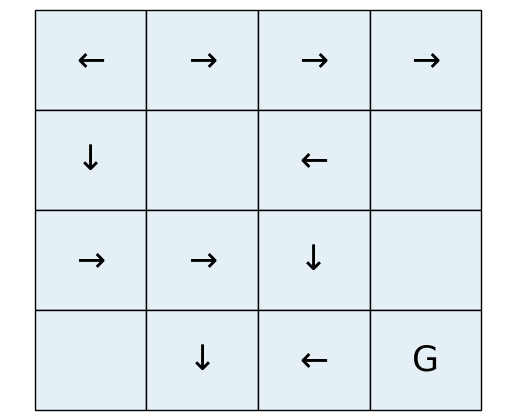

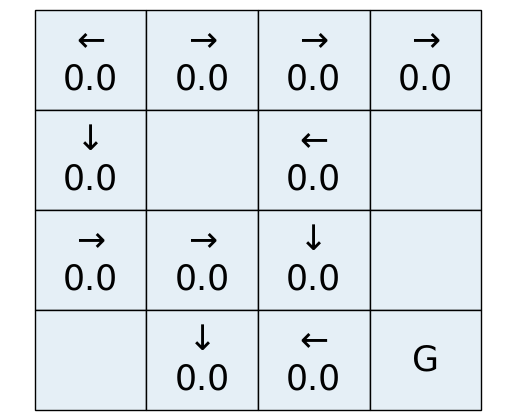

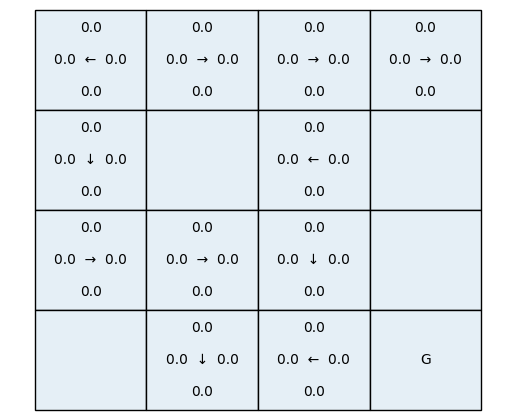

In [6]:
plot = Plot(map_size=4)
plot.initialize_all_tables()
plot.show_all_tables()

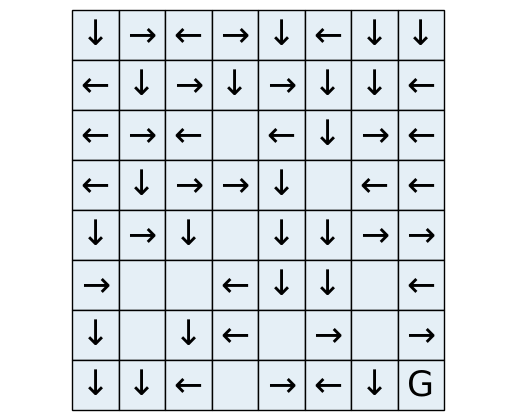

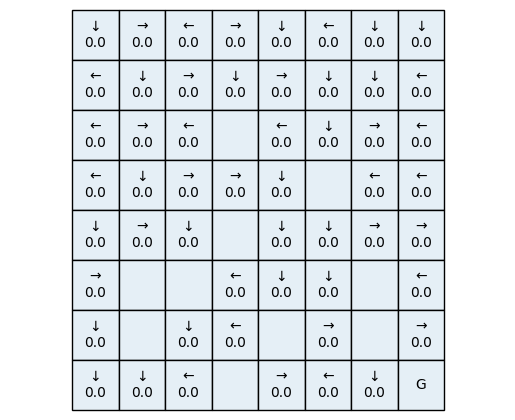

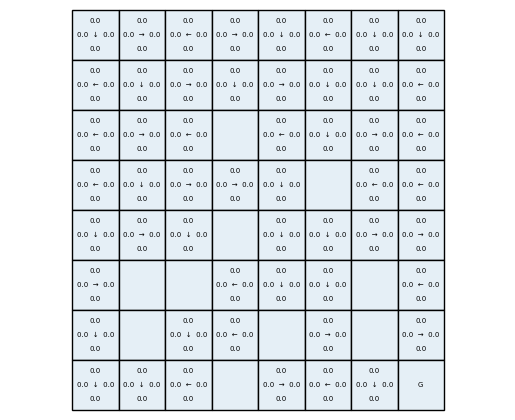

In [7]:
# For an 8 by 8 environment.
plot = Plot(map_size=8)
plot.initialize_all_tables()
plot.show_all_tables()

https://gymnasium.farama.org/environments/toy_text/frozen_lake/

The above link contains all you need to know about the environment.

The Policy is randomly initialized. There are no algorithms implemented for this and so value table and qtable are initialized to 0.

Good Luck for the assignment! If you want any help, you can ask for help from the instructor or Mahen Mughal on Slack.

**a)** Find the optimal policy, value table and q table for both frozen lake 4 by 4 environments using  

    i) Policy Iteration  
    ii) Value Iteration  

**b)** Perform part a on 8 by 8 frozen lake environment  

**c)** Find success rate on 100000 iterations for the optimal policy for both 4 by 4 environment and 8 by 8 environment.  

**d)** Do you think this should be the success rate for the 8 by 8 environment. If not, why not?


# Policy Iteration

Without gymnasium library

In [34]:
class PolicyIteration(RLTables):
    def __init__(self, map_size,terminal_states,is_slippery=False,sucess_rate=1/3):
        super().__init__(map_size)
        self.terminal_states=terminal_states
        self.is_slippery=is_slippery
        self.success_rate=sucess_rate
        self.perpendicular_rate=(1-self.success_rate)/2 #get prob for perpendicular states
                
        self.initialize_all_tables()

    def move(self,row,col,action):
        if action == 0:
            col=max(col-1,0)
        elif action == 1:
            row=min(row+1,self.map_size-1)
        elif action == 2:
            col=min(self.map_size-1,col+1)
        elif action == 3:
            row=max(row-1,0)

            
        next_state=row*self.map_size+col
        
        return next_state
        
    # return next state,reward given a state,action
    def get_next_state(self,state,action):
        
        #initialize , stay in same state if in terminal states with reward 0
        next_state,reward=state,0

        if state not in self.terminal_states and state!=self.goal_state:
            row, col = divmod(state, self.map_size)
            
            #deterministic outcomes, always move in intended direction
            if self.is_slippery==False:
                
                next_state=self.move(row,col,action)
                #get immediate reward from reward array defined for all states
                reward=self.reward[next_state]

                return next_state,reward
                
            #probabilistic outcomes
            else:
                #get left and right actions
                left_action = (action - 1) % 4
                right_action = (action + 1) % 4

                transitions = [
                    (self.success_rate, self.move(row, col, action)),      # move in intended direction with success rate 
                    (self.perpendicular_rate, self.move(row, col, left_action)), # move in left of intended with success_rate/2
                    (self.perpendicular_rate, self.move(row, col, right_action)) # right of intended
                ]

                # randomly sample according to probability
                probs, next_states = zip(*[(p, s) for p, s in transitions])
                chosen_state = np.random.choice(next_states, p=probs)
                reward = self.reward[chosen_state]
                return chosen_state, reward


            
    def policy_evaluation(self,state,action,gamma=0.8):

        if self.is_slippery==False:
            next_state,reward=self.get_next_state(state,action) #defines p-function 

            new_value=reward+gamma*self.value_table[next_state] 
        else:
            # expected value over possible outcomes
            row, col = divmod(state, self.map_size)

            nexts = []
            for prob, a in zip([self.success_rate, self.perpendicular_rate, self.perpendicular_rate], [action, (action-1)%4, (action+1)%4]):
                next_state = self.move(row, col, a)
                r = self.reward[next_state]
                nexts.append(prob * (r + gamma * self.value_table[next_state]))

            new_value = sum(nexts)
        
        return new_value
    
    def get_action_value(self, state, action, gamma):
        
        if state in self.terminal_states or state == self.goal_state:
            return 0.0

        row, col = divmod(state, self.map_size)

        if not self.is_slippery:
            next_state = self.move(row, col, action)
            reward = self.reward[next_state]
            return reward + gamma * self.value_table[next_state]

        else:
            # stochastic case
            left_action = (action - 1) % 4
            right_action = (action + 1) % 4

            transitions = [
                (self.success_rate, self.move(row, col, action)), #move with success_rate in intended direction
                (self.perpendicular_rate, self.move(row, col, left_action)), #move with perpendicular rate in perpendicular direction i.e (1-success_Rate)/2
                (self.perpendicular_rate, self.move(row, col, right_action))
            ]

            q_val = 0
            for prob, next_state in transitions:
                reward = self.reward[next_state]
                q_val += prob * (reward + gamma * self.value_table[next_state])

            return q_val

    def improve_policy(self):
        new_policy = np.zeros_like(self.policy)

        for s in range(self.q_table.shape[0]):
            if s in self.terminal_states:
                new_policy[s] = -1
            elif s == self.goal_state:
                new_policy[s] = -2
            else:
                # Greedy policy w.r.t q-table (action-value function)
                if np.all(self.q_table[s] == 0):
                    new_policy[s] = np.random.choice(4)
                else:
                    new_policy[s] = np.argmax(self.q_table[s])
        return new_policy

            
    def policy_improvement(self, gamma=0.8, threshold=10e-4, eval_epochs=1000, improv_epochs=100000):
        for epoch in range(improv_epochs):
            for _ in range(eval_epochs):
                delta = 0
                new_value_table = np.copy(self.value_table)

                for state in range(self.total_states):
                    if state in self.terminal_states or state == self.goal_state:
                        continue

                    action = self.policy[state]  
                    new_value = self.policy_evaluation(state, action, gamma)
                    delta = max(delta, abs(new_value_table[state] - new_value))
                    new_value_table[state] = new_value

                self.value_table = new_value_table.copy()

                if delta < threshold:
                    break

            for state in range(self.total_states):
                if state in self.terminal_states or state == self.goal_state:
                    continue

                for action in range(4):
                    self.q_table[state, action] = self.get_action_value(state, action, gamma)

            new_policy = self.improve_policy()

            if np.all(new_policy == self.policy):
                print("optimal policy found")
                break

            self.policy = new_policy.copy()


#map_size=4x4
# making an object and testing policy iteration for frozen lake environment
is_slippery=True
PI=PolicyIteration(map_size=4,terminal_states=terminal_states_4,is_slippery=is_slippery)        
PI.policy_improvement(gamma=1)

print(f"After policy iteration-4x4: gamma= {1} is_slippery= {is_slippery}:\n")
PI.print_all_tables()

optimal policy found
After policy iteration-4x4: gamma= 1 is_slippery= True:

Value Table
[0.80165741 0.79387628 0.78829646 0.78538356 0.80322219 0.
 0.51341229 0.         0.80624463 0.81051664 0.75314908 0.
 0.         0.87310882 0.93637848 0.        ]

Q-Table
[[0.802179   0.79958529 0.79958529 0.7990637 ]
 [0.53184456 0.52998462 0.52739091 0.79461005]
 [0.69852834 0.69755738 0.69569744 0.78918544]
 [0.52456001 0.52456001 0.52358904 0.78635453]
 [0.80370808 0.53648894 0.53596735 0.53495986]
 [0.         0.         0.         0.        ]
 [0.51381518 0.25104969 0.51381518 0.26276549]
 [0.         0.         0.         0.        ]
 [0.53648894 0.53892042 0.53791294 0.80666115]
 [0.55978449 0.81083418 0.54208597 0.5197979 ]
 [0.7534358  0.58229837 0.48326359 0.44130964]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.56120849 0.60316243 0.87333464 0.58229837]
 [0.85421213 0.93649577 0.89650919 0.8754193 ]
 [0.         0.         0.      

In [35]:
#map_size=8x8
# making an object and testing policy iteration for frozen lake environment
is_slippery=True
PI=PolicyIteration(map_size=8,terminal_states=terminal_states_8,is_slippery=is_slippery)        
PI.policy_improvement(gamma=1)

print(f"After policy iteration-8x8: gamma= {1}: is_slippery= {is_slippery}:\n")
PI.print_all_tables()

optimal policy found
After policy iteration-8x8: gamma= 1: is_slippery= True:

Value Table
[0.98219135 0.983031   0.98426161 0.98581164 0.98769453 0.98995729
 0.99259964 0.99481183 0.98197538 0.98261341 0.98370376 0.98505287
 0.98693577 0.98907849 0.99179494 0.99503858 0.96788175 0.95028924
 0.90162946 0.         0.84467356 0.93615303 0.97535372 0.99548216
 0.95537845 0.89676805 0.77204194 0.46123834 0.61239363 0.
 0.93947045 0.9961232  0.94499628 0.78636237 0.51913934 0.
 0.53179376 0.60555698 0.84718452 0.99693367 0.9370282  0.
 0.         0.16427889 0.37792867 0.43791704 0.         0.99787816
 0.93162795 0.         0.18110808 0.11505328 0.         0.33048512
 0.         0.99891538 0.92889576 0.67781178 0.42879659 0.
 0.2767929  0.55361283 0.7767929  0.        ]

Q-Table
[[0.98211936 0.98239924 0.98239924 0.98247123]
 [0.98261192 0.98302212 0.98330201 0.98316132]
 [0.98366546 0.98418213 0.98459234 0.98436808]
 [0.98504204 0.98566967 0.98618635 0.9859226 ]
 [0.98681398 0.98756823 0.98

# Value Iteration

In [ ]:
class ValueIteration(RLTables):
    def __init__(self, map_size, terminal_states, is_slippery=False, success_rate=1/3):
        super().__init__(map_size)
        self.terminal_states = terminal_states
        self.is_slippery = is_slippery
        self.success_rate = success_rate
        self.perpendicular_rate = (1 - self.success_rate) / 2
        self.initialize_all_tables()

    def move(self, row, col, action):
        if action == 0:  
            col = max(col - 1, 0)
        elif action == 1:
            row = min(row + 1, self.map_size - 1)
        elif action == 2:
            col = min(col + 1, self.map_size - 1)
        elif action == 3:
            row = max(row - 1, 0)

        return row * self.map_size + col

    def get_action_value(self, state, action, gamma):
        if state in self.terminal_states or state == self.goal_state:
            return 0.0

        row, col = divmod(state, self.map_size)

        if not self.is_slippery:
            next_state = self.move(row, col, action)
            reward = self.reward[next_state]
            return reward + gamma * self.value_table[next_state]

        else:
            # stochastic case
            left_action = (action - 1) % 4
            right_action = (action + 1) % 4

            transitions = [
                (self.success_rate, self.move(row, col, action)),
                (self.perpendicular_rate, self.move(row, col, left_action)),
                (self.perpendicular_rate, self.move(row, col, right_action))
            ]

            q_val = 0
            for prob, next_state in transitions:
                reward = self.reward[next_state]
                q_val += prob * (reward + gamma * self.value_table[next_state])

            return q_val

    def value_iteration(self, gamma=0.8, threshold=10e-4, improv_epochs=10000):
        for epoch in range(improv_epochs):
            new_value = np.copy(self.value_table)
            delta = 0
            for state in range(self.total_states):
                if state in self.terminal_states or state == self.goal_state:
                    continue
                
                q_values=[]
                for action in range(4):
                    new_v=self.get_action_value(state, action, gamma)
                    self.q_table[state,action]=new_v
                    q_values.append(new_v)

                best_value = max(q_values)
                delta = max(delta, abs(best_value - new_value[state]))
                new_value[state] = best_value

            self.value_table = new_value.copy()

            if delta < threshold:
                break

            new_policy = self.improve_policy()

            if np.all(new_policy == self.policy):
                print("optimal policy found")
                break

            self.policy = new_policy.copy()

    def improve_policy(self):
        new_policy = np.zeros_like(self.policy)

        for s in range(self.q_table.shape[0]):
            if s in self.terminal_states:
                new_policy[s] = -1
            elif s == self.goal_state:
                new_policy[s] = -2
            else:
                # Greedy policy w.r.t q-table (action-value function)
                if np.all(self.q_table[s] == 0):
                    new_policy[s] = np.random.choice(4)
                else:
                    new_policy[s] = np.argmax(self.q_table[s])
        return new_policy


#map_size=4x4
# making an object and testing policy iteration for frozen lake environment
is_slippery=True
VI=ValueIteration(map_size=4,terminal_states=terminal_states_4,is_slippery=is_slippery)        
VI.value_iteration(gamma=1)

print(f"After value iteration-4x4: gamma= {1} is_slippery= {is_slippery}:\n")
PI.print_all_tables()

After value iteration-4x4: gamma= 1 is_slippery= True:

Value Table
[0.98219135 0.983031   0.98426161 0.98581164 0.98769453 0.98995729
 0.99259964 0.99481183 0.98197538 0.98261341 0.98370376 0.98505287
 0.98693577 0.98907849 0.99179494 0.99503858 0.96788175 0.95028924
 0.90162946 0.         0.84467356 0.93615303 0.97535372 0.99548216
 0.95537845 0.89676805 0.77204194 0.46123834 0.61239363 0.
 0.93947045 0.9961232  0.94499628 0.78636237 0.51913934 0.
 0.53179376 0.60555698 0.84718452 0.99693367 0.9370282  0.
 0.         0.16427889 0.37792867 0.43791704 0.         0.99787816
 0.93162795 0.         0.18110808 0.11505328 0.         0.33048512
 0.         0.99891538 0.92889576 0.67781178 0.42879659 0.
 0.2767929  0.55361283 0.7767929  0.        ]

Q-Table
[[0.98211936 0.98239924 0.98239924 0.98247123]
 [0.98261192 0.98302212 0.98330201 0.98316132]
 [0.98366546 0.98418213 0.98459234 0.98436808]
 [0.98504204 0.98566967 0.98618635 0.9859226 ]
 [0.98681398 0.98756823 0.98819586 0.98782116]
 [0.

In [26]:
#map_size=8x8
# making an object and testing policy iteration for frozen lake environment
is_slippery=True
VI=ValueIteration(map_size=8,terminal_states=terminal_states_8,is_slippery=is_slippery)        
VI.value_iteration(gamma=1)

print(f"After value iteration-4x4: gamma= {1} is_slippery= {is_slippery}:\n")
PI.print_all_tables()

After value iteration-4x4: gamma= 1 is_slippery= True:

Value Table
[0.80032171 0.79254595 0.78702511 0.78416057 0.8020112  0.
 0.51282068 0.         0.80526714 0.80985245 0.75264422 0.
 0.         0.87264147 0.93613735 0.        ]

Q-Table
[[0.80032171 0.79766541 0.79766541 0.79708824]
 [0.53050672 0.52862074 0.52596444 0.79254595]
 [0.69676719 0.69578863 0.69390265 0.78702511]
 [0.5230999  0.5230999  0.52212134 0.78416057]
 [0.8020112  0.53542969 0.53485251 0.5337402 ]
 [0.         0.         0.         0.        ]
 [0.51282068 0.25078145 0.51282068 0.26203923]
 [0.         0.         0.         0.        ]
 [0.53542969 0.53810846 0.53699614 0.80526714]
 [0.559071   0.80985245 0.54158145 0.51905245]
 [0.75264422 0.58184147 0.48280677 0.44064021]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.56063746 0.60280402 0.87264147 0.58184147]
 [0.85358547 0.93613735 0.8961188  0.87491478]
 [0.         0.         0.         0.        ]]
Policy

# critical question

As the player can only move in local neighborhood in 4 directions(left,right,up,down) , the size of frozen lake environment does not matter and hence the success rate will remain same as 4x4 grid because irrespective of the frozen lake size the player moves in one intended and 2 perpendicular directions.

